**Cell 1 — Imports and config**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm
from scipy.optimize import minimize   # was missing — required fix
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

BMW_RET_CSV = os.path.join(BASE_DIR, "BMW_DE_log_returns.csv")
VOW_RET_CSV = os.path.join(BASE_DIR, "VOW_DE_log_returns.csv")
BMW_PRICE_CSV = os.path.join(BASE_DIR, "BMW_DE_price_volume.csv")
VOW_PRICE_CSV = os.path.join(BASE_DIR, "VOW_DE_price_volume.csv")
BACKTEST_CSV = os.path.join(BASE_DIR, "Clayton_GARCH_BMW_VOW_backtest.csv")

WINDOW = 250
N_MC = 10_000
ALPHA = 0.05
START_DATE, END_DATE = "2020-01-01", "2026-04-30"

**Cell 2 — Load returns and prices**

In [2]:
r_bmw = pd.read_csv(BMW_RET_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_vow = pd.read_csv(VOW_RET_CSV, parse_dates=["Date"]).set_index("Date")["Close"]

returns = pd.concat([r_bmw, r_vow], axis=1)
returns.columns = ["BMW", "VOW"]
returns = returns.dropna().loc[START_DATE:END_DATE]

p_bmw = pd.read_csv(BMW_PRICE_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
p_vow = pd.read_csv(VOW_PRICE_CSV, parse_dates=["Date"]).set_index("Date")["Close"]

prices = pd.concat([p_bmw, p_vow], axis=1).dropna()
prices.columns = ["BMW", "VOW"]
prices = prices.loc[returns.index]

bmw_price = prices["BMW"].values
vow_price = prices["VOW"].values
bmw_ret = returns["BMW"].values
vow_ret = returns["VOW"].values
dates = returns.index
T = len(bmw_ret)

**Cell 3 — Model functions (GARCH fit + Clayton copula)**

In [3]:
def fit_garch11(r):
    def neg_loglik(params):
        omega, alpha, beta = params
        if omega <= 0 or alpha <= 0 or beta <= 0 or alpha + beta >= 1:
            return 1e10
        sig2 = np.empty(len(r))
        sig2[0] = np.var(r)
        for t in range(1, len(r)):
            sig2[t] = omega + alpha * r[t-1]**2 + beta * sig2[t-1]
        return 0.5 * np.sum(np.log(sig2) + r**2 / sig2)

    res = minimize(neg_loglik, [1e-5, 0.08, 0.90],
                    method='L-BFGS-B',
                    bounds=[(1e-8, None), (1e-8, 0.5), (1e-8, 0.9999)])
    omega, alpha, beta = res.x
    sig2 = np.empty(len(r))
    sig2[0] = np.var(r)
    for t in range(1, len(r)):
        sig2[t] = omega + alpha * r[t-1]**2 + beta * sig2[t-1]
    return omega, alpha, beta, sig2

def clayton_loglik(theta, u, v):
    if theta <= 0:
        return 1e10
    u = np.clip(u, 1e-8, 1-1e-8)
    v = np.clip(v, 1e-8, 1-1e-8)
    log_c = (np.log(1 + theta)
             + (-1 - theta) * (np.log(u) + np.log(v))
             + (-1/theta - 2) * np.log(u**(-theta) + v**(-theta) - 1))
    return -np.sum(log_c)

def fit_clayton(u, v):
    res = minimize(lambda t: clayton_loglik(t[0], u, v), [2.0],
                    method='L-BFGS-B', bounds=[(1e-4, 50)])
    return res.x[0]

def clayton_sample(theta, n_sim, rng):
    """Fixed conditional inversion formula for Clayton copula."""
    u = rng.uniform(0, 1, n_sim)
    p = rng.uniform(0, 1, n_sim)
    v = (1 + u**(-theta) * (p**(-theta/(1+theta)) - 1)) ** (-1/theta)
    return u, np.clip(v, 1e-8, 1-1e-8)

**Cell 4 — Run rolling backtest, save results**

In [4]:
if os.path.exists(BACKTEST_CSV):
    print(f"File already exists, skipping backtest: {BACKTEST_CSV}")
    backtest = pd.read_csv(BACKTEST_CSV, index_col="Date", parse_dates=True)
else:
    rng = np.random.default_rng(42)
    VaR_list, PL_list, dates_list = [], [], []

    for t in range(WINDOW, T):
        rb = bmw_ret[t-WINDOW:t]
        rs = vow_ret[t-WINDOW:t]

        omega_b, alpha_b, beta_b, sig2_b = fit_garch11(rb)
        omega_s, alpha_s, beta_s, sig2_s = fit_garch11(rs)

        z_b = rb / np.sqrt(sig2_b)
        z_s = rs / np.sqrt(sig2_s)

        u_b = norm.cdf(z_b)
        u_s = norm.cdf(z_s)

        theta = fit_clayton(u_b, u_s)
        u_sim, v_sim = clayton_sample(theta, N_MC, rng)

        z_b_sim = norm.ppf(u_sim)
        z_s_sim = norm.ppf(v_sim)

        sig2_b_fc = omega_b + beta_b * sig2_b[-1] + alpha_b * rb[-1]**2
        sig2_s_fc = omega_s + beta_s * sig2_s[-1] + alpha_s * rs[-1]**2

        r_b_sim = z_b_sim * np.sqrt(sig2_b_fc)
        r_s_sim = z_s_sim * np.sqrt(sig2_s_fc)

        R_b = np.exp(r_b_sim) - 1
        R_s = np.exp(r_s_sim) - 1

        # FIXED: use price[t-1], the position value known before day t's move
        pl_mc = bmw_price[t-1] * R_b + vow_price[t-1] * R_s
        VaR_list.append(np.percentile(pl_mc, 100 * ALPHA))

        PL_list.append(
            bmw_price[t-1] * (np.exp(bmw_ret[t]) - 1) +
            vow_price[t-1] * (np.exp(vow_ret[t]) - 1)
        )
        dates_list.append(dates[t])

    backtest = pd.DataFrame({
        "VaR": VaR_list, "PL": PL_list
    }, index=pd.Index(dates_list, name="Date"))
    backtest.to_csv(BACKTEST_CSV)
    print(f"Backtest results saved to {BACKTEST_CSV}")

VaR_arr = backtest["VaR"].values
PL_arr = backtest["PL"].values
dates_arr = backtest.index.values

exceedances = PL_arr < VaR_arr
print(f"Exceedance ratio: {exceedances.mean():.4f}  (target={ALPHA})")
print(f"N exceedances: {exceedances.sum()} / {len(PL_arr)}")

Backtest results saved to ../Data/Clayton_GARCH_BMW_VOW_backtest.csv
Exceedance ratio: 0.0411  (target=0.05)
N exceedances: 56 / 1361


**Cell 5 — Plot, display and save**

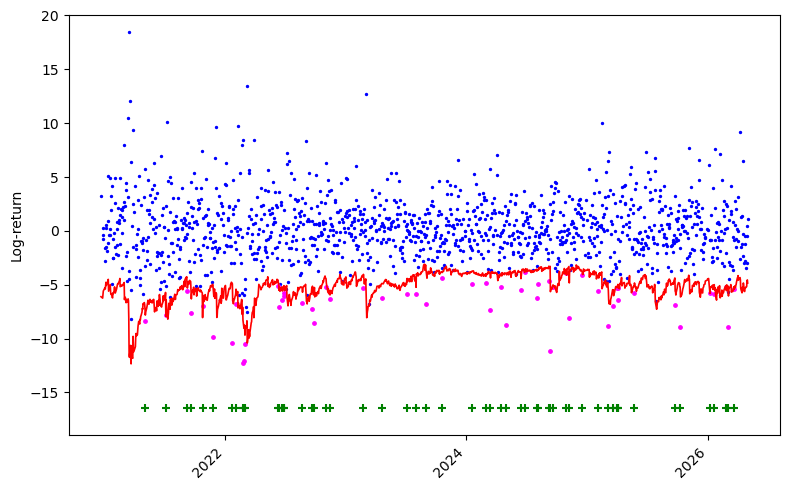

Done.


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(dates_arr[~exceedances], PL_arr[~exceedances],
           s=2, color='blue', label='Profit/Loss', zorder=2)
ax.scatter(dates_arr[exceedances], PL_arr[exceedances],
           s=6, color='magenta', label='Exceedances', zorder=3)
ax.plot(dates_arr, VaR_arr, color='red', linewidth=1.2, label='VaR', zorder=4)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_ylabel("Log-return")
ax.grid(False)

plt.tight_layout()
y_bot, y_top = ax.get_ylim()
span = y_top - y_bot
ax.set_ylim(y_bot - 0.15 * span, y_top)

y_rug = y_bot - 0.075 * span
ax.scatter(dates_arr[exceedances], np.full(exceedances.sum(), y_rug),
           marker='+', color='green', s=30, zorder=5, clip_on=False)

plt.savefig(os.path.join(OUTPUT_DIR, "Clayton_GARCH_BMW_VOW.png"),
            dpi=200, transparent=True, bbox_inches='tight')
plt.show()
print("Done.")